In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error

In [15]:
# Load data
df = pd.read_csv("/Users/mariahloehr/IICD/IICD/Data/cell_cycle_tidied.csv")

# Separate features and target
X = df.drop(columns=['phase', 'age', 'PHATE_1', 'PHATE_2'])
y = df['age']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=949)

In [3]:
# Create bins for y
bins = np.percentile(y, np.linspace(0, 100, 11))  # deciles
y_binned = np.digitize(y, bins[1:-1])  # assign bin labels

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y_binned, random_state=949
)

In [71]:
# Define MLP regressor
mlp = MLPRegressor(max_iter=4000, learning_rate = 'adaptive', random_state=949)

In [72]:
# Hyperparameter tuning
param_grid = {
    'hidden_layer_sizes': [
        (300,300),
        (300, 300, 300),
        (300, 300, 300, 300),
    ],
    #'learning_rate_init': [0.0001, 0.001],
    'alpha': [10,50,100]  # L2 penalty
    #'learning_rate_init': [0.001, 0.01, 0.1]  # initial LR for adaptive strategy
}


# GridSearchCV using RMSE as scoring

grid_search = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    cv=10,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Fit model
grid_search.fit(X_train, y_train)

# Output best parameters and score (convert to positive RMSE)
print("Best parameters:", grid_search.best_params_)


Best parameters: {'alpha': 10, 'hidden_layer_sizes': (300, 300, 300)}


/Users/mariahloehr/IICD/IICD/sklearn-env/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/mariahloehr/IICD/IICD/sklearn-env/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/mariahloehr/IICD/IICD/sklearn-env/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/mariahloehr/IICD/IICD/sklearn-env/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't conv

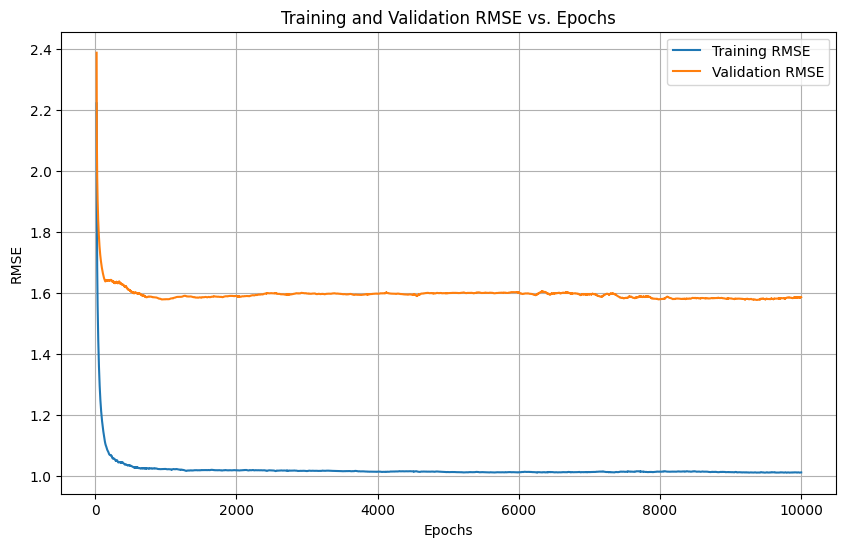

In [43]:
# tuning epochs

mlp = MLPRegressor(max_iter=1, 
                   hidden_layer_sizes = (300,300,300), 
                   learning_rate = 'adaptive', 
                   learning_rate_init = 0.0001, 
                   alpha = 25,
                   random_state=949,
                   warm_start=True)

# track rmse
n_epochs = 10000

train_rmse = []
val_rmse = []
epochs_recorded = []

def moving_average(data, window_size=20):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

for epoch in range(1, n_epochs):
    mlp.fit(X_train, y_train)  # One epoch
    
    y_tr_pred = mlp.predict(X_train)
    y_val_pred = mlp.predict(X_test)
    
    train_rmse.append(root_mean_squared_error(y_train, y_tr_pred))
    val_rmse.append(root_mean_squared_error(y_test, y_val_pred))
    epochs_recorded.append(epoch)

smoothed_val_rmse = moving_average(val_rmse, window_size=20)
smoothed_train_rmse = moving_average(train_rmse, window_size=20)
epochs_smoothed = np.arange(20, len(val_rmse)+1)

# Plot
plt.figure(figsize=(10,6))
plt.plot(epochs_smoothed, smoothed_train_rmse, label='Training RMSE')
plt.plot(epochs_smoothed, smoothed_val_rmse, label='Validation RMSE')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.title('Training and Validation RMSE vs. Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Retrain with best estimators

mlp = MLPRegressor(max_iter=2000, 
                   hidden_layer_sizes = (300,300,300), 
                   learning_rate = 'adaptive', 
                   learning_rate_init = 0.0001, 
                   alpha = 25,
                   random_state=949)
mlp.fit(X_train, y_train)

# Predictions
y_train_pred = mlp.predict(X_train)
y_test_pred = mlp.predict(X_test)

In [35]:
# Evaluation
# Calculate RMSE
rmse_train = root_mean_squared_error(y_train, y_train_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("=== Training Set ===")
print(f"RMSE: {rmse_train:.4f}")

print("\n=== Test Set ===")
print(f"RMSE: {rmse_test:.4f}")

# For training set
df_train = pd.DataFrame({
    'true_age': y_train,
    'pred_age': y_train_pred,
    'phase': df.loc[y_train.index, 'phase']  # get phase for train samples
})

rmse_per_phase_train = df_train.groupby('phase').apply(
    lambda x: root_mean_squared_error(x['true_age'], x['pred_age'])
)

print("RMSE per phase (Train):")
print(rmse_per_phase_train)

# For test set
df_test = pd.DataFrame({
    'true_age': y_test,
    'pred_age': y_test_pred,
    'phase': df.loc[y_test.index, 'phase']  # get phase for test samples
})

rmse_per_phase_test = df_test.groupby('phase').apply(
    lambda x: np.sqrt(mean_squared_error(x['true_age'], x['pred_age']))
)

print("\nRMSE per phase (Test):")
print(rmse_per_phase_test)

=== Training Set ===
RMSE: 0.9793

=== Test Set ===
RMSE: 1.6033
RMSE per phase (Train):
phase
G0    1.013499
G1    0.742783
G2    1.144041
M     3.637319
S     1.011892
dtype: float64

RMSE per phase (Test):
phase
G0    1.628550
G1    1.308955
G2    1.815087
M     8.505172
S     1.417622
dtype: float64


/var/folders/1s/bvxr71hj0hqgyk_jk6k7wkm80000gn/T/ipykernel_88366/3370718067.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_per_phase_train = df_train.groupby('phase').apply(
/var/folders/1s/bvxr71hj0hqgyk_jk6k7wkm80000gn/T/ipykernel_88366/3370718067.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_per_phase_test = df_test.groupby('phase').apply(


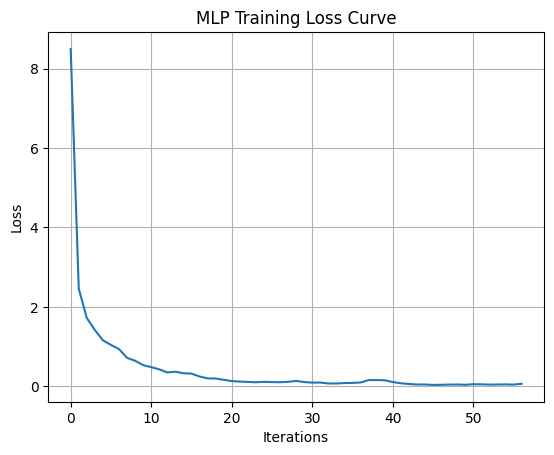

In [10]:
plt.plot(mlp.loss_curve_)
plt.title('MLP Training Loss Curve')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [33]:
# === Load existing results DataFrame ===
results_df = pd.read_csv("/Users/mariahloehr/IICD/IICD/Bar Plot/regression_results.csv", index_col=0)

# === Set values ===
model_name = "MLP (full)"  # or whatever is appropriate
results_df.loc[model_name, 'Overall'] = rmse_test

# Fill in per-phase RMSEs
for phase in ['G0', 'G1', 'G2', 'M', 'S']:
    if phase in rmse_per_phase_test.index:
        results_df.loc[model_name, phase] = rmse_per_phase_test[phase]

# === Save updated results ===
results_df.to_csv("/Users/mariahloehr/IICD/IICD/Bar Plot/regression_results.csv")

In [39]:
# === Load existing results DataFrame ===
results_df = pd.read_csv("/Users/mariahloehr/IICD/IICD/Bar Plot/5_minipatch_results.csv", index_col=0)

# === Set values ===
model_name = "MLP"  # or whatever is appropriate
results_df.loc[model_name, 'Overall'] = rmse_test

# Fill in per-phase RMSEs
for phase in ['G0', 'G1', 'G2', 'M', 'S']:
    if phase in rmse_per_phase_test.index:
        results_df.loc[model_name, phase] = rmse_per_phase_test[phase]

# === Save updated results ===
results_df.to_csv("/Users/mariahloehr/IICD/IICD/Bar Plot/5_minipatch_results.csv")

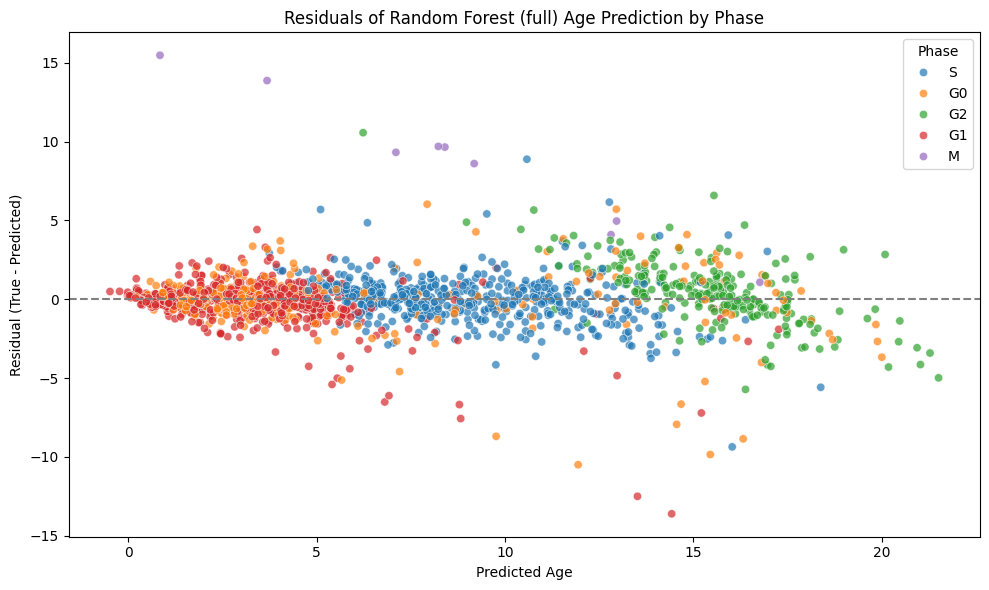

In [17]:
## PLOT RESIDUALS
# Create DataFrame for plotting
df_plot = pd.DataFrame({
    'True Age': y_test,
    'Predicted Age': y_test_pred,
    'Residual': y_test - y_test_pred,
    'Phase': df.loc[y_test.index, 'phase']
})

# Plot residuals
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_plot,
    x='Predicted Age',
    y='Residual',
    hue='Phase',
    palette='tab10',
    alpha=0.7
)
plt.axhline(0, color='gray', linestyle='--')
plt.title("Residuals of Random Forest (full) Age Prediction by Phase")
plt.xlabel("Predicted Age")
plt.ylabel("Residual (True - Predicted)")
plt.legend(title='Phase')
plt.tight_layout()

# Save the plot
plot_path = "mlp_regression_full.png"
plt.savefig(plot_path, dpi=300)
plt.show()

SHAP

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

/Users/mariahloehr/IICD/IICD/sklearn-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
explainer = shap.KernelExplainer(mlp.predict,X_train)
shap_values = explainer.shap_values(X_test,nsamples=100)

Using 7080 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
  2%|▏         | 29/1770 [02:47<2:33:44,  5.30s/it]/Users/mariahloehr/IICD/IICD/sklearn-env/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 8 iterations, i.e. alpha=3.528e-01, with an active set of 8 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
  2%|▏         | 42/1770 [04:00<2:46:06,  5.77s/it]/Users/mariahloehr/IICD/IICD/sklearn-env/lib/python3.12/site-packages/shap/explainers/_kernel.py:708: UserWarning: Linear regression equation is singular, a least squares solutions is used instead.
To avoid this situation and get a regular matrix do one of the following:
1) turn up the number of samples,
2) turn up the L1 regularization with 

In [41]:

# Select a background sample (needed for KernelExplainer)
background = shap.sample(X_train, 300, random_state=42)

# Create the explainer
explainer = shap.KernelExplainer(mlp.predict, background)

# Sample a subset of test data for explanation (to keep it fast)
X_sample = shap.sample(X_test, 300, random_state=42)

# Compute SHAP values
shap_values = explainer.shap_values(X_sample)

Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
  4%|▍         | 12/300 [01:22<32:54,  6.86s/it]


KeyboardInterrupt: 

In [10]:
shap_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values(by='importance', ascending=False)

In [1]:
# Plot top 10 features
top_20 = shap_importance.head(20)
plt.figure(figsize=(8, 6))
plt.barh(top_20['feature'][::-1], top_20['importance'][::-1])
plt.xlabel('Mean SHAP Value')
plt.title('Top 20 Feature Importances (MLP)')
plt.tight_layout()
#plt.savefig('top_10_feature_importance_rf.png')

NameError: name 'shap_importance' is not defined